In [20]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [21]:
test_dict = {}
train_dict = {}
root_path = '../datasets/cifar-10-batches-py/'


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

accepted_keys = [b'labels', b'data'] ## select keys from [b'batch_label', b'labels', b'data', b'filenames']
for dir in os.listdir(root_path):
    if dir == 'batches.meta':
        pass
    elif dir == 'test_batch':
        test_batch = unpickle(os.path.join(root_path, dir))
        test_dict.update((k,np.array(v)) for k,v in test_batch.items() if k in accepted_keys)
    else:
        train_batch = unpickle(os.path.join(root_path, dir))
        if not train_dict:
            train_dict.update((k,np.array(v)) for k,v in train_batch.items() if k in accepted_keys)
        else:
            for key in accepted_keys:
                train_dict[key] = np.concatenate((train_dict[key], train_batch[key]), axis=0)


## CIFAR data's shape are (N, H*W*C). 
## If you want to convert them into numpy-standard (N, H, W, C) shape, run following codes.
def numpy2rgb(arr: np.ndarray) -> np.ndarray:
    batch_size = len(arr)
    arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,2,3,1)
    
    return arr


train_dict[b'data'] = numpy2rgb(train_dict[b'data'])
test_dict[b'data'] = numpy2rgb(test_dict[b'data'])

In [22]:
def normalize(data: np.ndarray, mean: int=None, std: int=None) -> np.ndarray:
    if mean == None:
        mean = np.mean(data)
        
    if std == None:
        std = np.std(data)
    
    data = (data - mean) / std
    return data

In [23]:
x_train, t_train = normalize(train_dict[b'data']), train_dict[b'labels']
x_test, t_test = normalize(test_dict[b'data']), test_dict[b'labels']

print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 32, 32, 3)
2.09341038199596
(50000,)


In [24]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 32, 32, 3)
2.09341038199596
(50000,)


In [25]:
network_dict = {
                'leaky-0.2': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std='relu', weight_decay_lambda=0.1, use_dropout=True, dropout_ration=0.2, use_batchnorm=True),
                'leaky-0.5': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std='relu', weight_decay_lambda=0.1, use_dropout=True, dropout_ration=0.5, use_batchnorm=True),
                'leaky-0.7': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std='relu', weight_decay_lambda=0.1, use_dropout=True, dropout_ration=0.7, use_batchnorm=True),c
                }

SyntaxError: ':' expected after dictionary key (2831005001.py, line 4)

In [ ]:
network_dict['leaky'].params.keys()

dict_keys(['W1', 'b1', 'W2', 'b2', 'gamma1', 'beta1'])

In [ ]:
# 하이퍼 파라메터
iters_num = 50_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [ ]:
output_dict = {}
for key, network in network_dict.items():

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    print('='*10)
    print('\n\n')


=== leaky network training start ===


--- leaky result report ---
train acc, test acc | 0.17642, 0.1779
--- leaky result report ---
train acc, test acc | 0.37784, 0.3741
--- leaky result report ---
train acc, test acc | 0.38664, 0.3855
--- leaky result report ---
train acc, test acc | 0.37946, 0.3757
--- leaky result report ---
train acc, test acc | 0.3407, 0.3392
--- leaky result report ---
train acc, test acc | 0.39934, 0.397
--- leaky result report ---
train acc, test acc | 0.38432, 0.3865
--- leaky result report ---
train acc, test acc | 0.39378, 0.3921
--- leaky result report ---
train acc, test acc | 0.3711, 0.3682
--- leaky result report ---
train acc, test acc | 0.38144, 0.3796
--- leaky result report ---
train acc, test acc | 0.37772, 0.381
--- leaky result report ---
train acc, test acc | 0.3809, 0.3791
--- leaky result report ---
train acc, test acc | 0.37846, 0.3771
--- leaky result report ---
train acc, test acc | 0.38184, 0.3807
--- leaky result report ---
train acc, test acc | 0.3772, 0.3715
--- leaky result

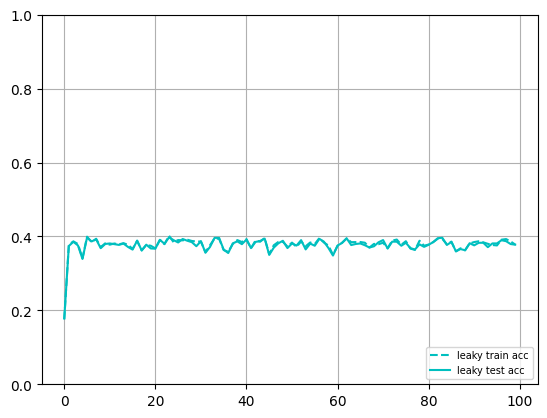

In [ ]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right', prop={'size':7})
plt.grid()